In [1]:
# python 3.8 서브 환경 구축
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')


[colab-compat] torch.load weights_only=False 패치 적용


In [2]:
!pip install -q gensim

# 0. 프로젝트 시작 전 준비

---

In [4]:
# 디렉토리 생성

!mkdir -p ./aiffel/transformer_chatbot

In [3]:
# KoNLPy 및 의존성 설치

# 1. 자바 및 필수 의존성 설치
!sudo apt-get install g++ openjdk-8-jdk python3-dev curl

# 2. pip 업그레이드 및 KoNLPy 설치
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
g++ is already the newest version (4:11.2.0-1ubuntu1).
g++ set to manually installed.
curl is already the newest version (7.81.0-1ubuntu1.24).
The following additional packages will be installed:
  at-spi2-core fonts-dejavu-core fonts-dejavu-extra gsettings-desktop-schemas
  javascript-common libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libjs-sphinxdoc libjs-underscore librsvg2-common libxcomposite1 libxt-dev
  libxtst6 libxxf86dga1 openjdk-8-jdk-headless openjdk-8-jre
  openjdk-8-jre-headless python3.10-dev session-migration x11-utils
Suggested packages:
  apache2 | lighttpd | httpd gvfs libxt-doc openjdk-8-demo openjdk-8-source
  visualvm libnss-mdns fonts-nanum fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei fonts-wqy-zenhei fonts-indic mesa-

In [8]:
# MeCab 설치

# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) || true # MeCab 설치하기
#  konlpy의 설치 스크립트가 시도하는 mecab-python-0.996은 오래된 패키지라 pyproject.toml이 없고, 최신 pip의 build isolation 방식과 호환이 안 돼서 실패

In [4]:
# python-mecab-ko 사용
!pip install python-mecab-ko

기존 예시 코드에서 `konlpy.tag.Mecab`를

```python
from mecab import MeCab
mecab = MeCab()
mecab.morphs("아버지가방에들어가신다")
```
로 바꿔서 진행한다

#  1. 번역 데이터 준비

## 라이브러리 로드

----

In [5]:
import numpy as np
import pandas as pd
import torch
import nltk
import gensim
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.0.2
2.2.2
2.11.0+cu128
3.9.1
4.4.0


## 데이터 다운로드

---

* [songys/Chatbot_data](https://github.com/songys/Chatbot_data) 에서 `ChatbotData.csv` 데이터를 저장하여 사용한다.
<br>

`csv` 파일이므로 `pandas` 라이브러리를 사용한다. <br>
데이터는 한 줄에 `Q,A,label`로 구성되어 있다. 데이터의 질문과 답변을 각각 `questions`, `answers` 변수에 나눠서 저장한다.


In [6]:
data_df = pd.read_csv("/content/aiffel/ChatbotData.csv")

# 각 열의 데이터를 변수에 저장
questions = data_df['Q']
answers = data_df['A']

print(len(questions))
print(len(answers))
print("\nSample Data Check: ")
print("Question: ", questions[0])
print("Answer: ", answers[0])


11823
11823

Sample Data Check: 
Question:  12시 땡!
Answer:  하루가 또 가네요.


# 2. 데이터 정제

---
데이터를 정제할 수 있는 preprocess_sentence() 함수 구현한다.

1. 영문자의 경우 모두 소문자로 변환
2. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하고 **정규식을 활용하여 모두 제거**

In [7]:
# 전처리 함수 정의

def preprocess_sentence(sentence):
  sentence = sentence.lower() # 영문자 : 대문자를 소문자로 변환
  sentence = re.sub(r"[^a-z0-9가-힣?.!,¿]+", " ", sentence)  #  한글, 영문, 숫자, 주요 특수문자를 제외한 나머지 제거
  return sentence



In [8]:
qustions_prep = list(map(preprocess_sentence, questions))
answers_prep = list(map(preprocess_sentence, answers))

print("전처리 완료!")

전처리 완료!


# 3. 데이터 토큰화

---

토큰화에는  *KoNLPy*의 `mecab` 클래스를 사용한다. \
\
다만, `MeCab` 이 설치에 실패하였으므로, `python-mecab-ko` 으로 대체하여 설치하였다.

토큰화 함수(`build_corpus()`는 다음의 조건을 만족해야 한다.
1. **소스 문장 데이터**와 **타겟 문장 데이터**를 입력으로 받는다.
2. 데이터를 앞서 정의한 **`preprocess_sentence()`** 함수로 **정제하고, 토큰화**한다.
3. 토큰화는 **전달받은 토크나이즈 함수를 사용**한다. (**`mecab.morphs`** 함수를 전달)
4. 토큰의 개수가 일정 길이 이상인 문장은 **데이터에서 제외**한다. (MAX_LEN = 40)
5. **중복되는 문장은 데이터에서 제외**한다. `소스 : 타겟` 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사한다. 중복 쌍이 흐트러지지 않도록 유의해서 수행한다.
<br>구현한 함수를 활용하여 `questions` 와 `answers` 를 각각 `que_corpus` , `ans_corpus` 에 토큰화하여 저장한다.

In [9]:
from mecab import MeCab

mecab = MeCab()
MAX_LEN = 40

def build_corpus(src_data, tgt_data, tokenize_func, max_len=MAX_LEN):
  que_corpus = []
  ans_corpus = []

  seen_src = set()
  seen_tgt = set()

  for src_sentence, tgt_sentence in zip(src_data, tgt_data):
    # 데이터 정제
    src_clean = preprocess_sentence(src_sentence)
    tgt_clean = preprocess_sentence(tgt_sentence)

    # 토큰화
    src_tokens = tokenize_func(src_clean)
    tgt_tokens = tokenize_func(tgt_clean)

    # 길이 제한을 넘으면 쌍 전체 제외
    if (len(src_tokens) > max_len) or len(tgt_tokens) > max_len:
      continue

    # 소스/타켓 각각 중복 점사(쌍이 흐트러지지 않도록 동시에 검사)
    src_key = src_clean
    tgt_key = tgt_clean

    if src_key in seen_src or tgt_key in seen_tgt:
      continue

    seen_src.add(src_key)
    seen_tgt.add(tgt_key)

    que_corpus.append(src_tokens)
    ans_corpus.append(tgt_tokens)

  return que_corpus, ans_corpus


print("토큰화 함수 정의 완료!")



토큰화 함수 정의 완료!


In [10]:
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs)

print(len(que_corpus))
print(len(ans_corpus))
print(que_corpus[0])
print(ans_corpus[0])

7739
7739
['12', '시', '땡', '!']
['하루', '가', '또', '가', '네요', '.']


중복되는 문장을 제외한 결과 소스/타켓 데이터가 각각 7737개 남았다. <br>
주어진 데이터의 양이 적은 편이기에, 데이터를 증가시켜서 학습에 사용할 데이터를 늘리는 작업이 필요하다고 판단된다.

# 4. Data Augmentation

---
중복을 제외하고 남은 데이터는 7737개로 적은 편에 속한다. 따라서 학습에 사용할 데이터의 양을 증가시키기 위해서 **Lexical Substitution** 을 적용한다. <br>


증강에 사용할 모델은 * [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors) 의 한국어로 사전 훈련된 Embedding 모델이다. Word2Vec로 학습된  `Korean (w)`의 `ko.bin` 파일을 이용한다.<br>

단, gensim 3.8.3이 코랩 환경에서 적용이 되지 않으므로, python3.8 서브 환경을 빠로 만들어서 그 안에서 변환한다. <br><br>

*Augmentation된 `que_corpus` 와 원본 `ans_corpus` 가 병렬을 이루도록, 이후엔 반대로 원본 `que_corpus` 와 Augmentation된 `ans_corpus` 가 병렬을 이루도록 하여 <b>전체 데이터가 원래의 3배가량으로 늘어나도록 한다.</b>*

#### **한국어로 사전 훈련된 Embedding 모델 다운로드 및 로드**

---

In [11]:
# Python 3.8 + gensim 3.8.3 서브 환경 생성

%%bash
conda create -n old_env python=3.8 -y
conda run -n old_env pip install gensim==3.8.3

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/envs/old_env

  added / updated specs:
    - python=3.8


The following NEW packages will be INSTALLED:

  _openmp_mutex      conda-forge/linux-64::_openmp_mutex-4.5-20_gnu 
  bzip2              conda-forge/linux-64::bzip2-1.0.8-hda65f42_9 
  ca-certificates    conda-forge/noarch::ca-certificates-2026.6.17-hbd8a1cb_0 
  ld_impl_linux-64   conda-forge/linux-64::ld_impl_linux-64-2.45.1-default_hbd61a6d_102 
  libffi             conda-forge/linux-64::libffi-3.7.0-h3435931_0 
  libgcc             conda-forge/linux-64::libgcc-15.2.0-he0feb66_19 
  libgcc-ng          conda-forge/linux-64::libgcc-ng-15.2.0-h69a702a_19 
  libgomp            conda-forge/linux-64::libgomp-15.2.0-he0feb66_19 
  liblzma            conda-forge/linux-64::liblzma-5.8.3-hb03c661_0 
  liblzma-devel      conda-forge/linux-64::liblzma-devel-5.8.3-hb03c661_0 
  libnsl             cond



==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [15]:
# 변환 스크립트 작성 후 old_env에서 실행

convert_script = """
from gensim.models import Word2Vec
import sys

src_path = sys.argv[1]
dst_path = sys.argv[2]

model = Word2Vec.load(src_path)
wv = model.wv
wv.save_word2vec_format(dst_path, binary=True)
print("변환 완료:", dst_path)
"""

with open("convert.py", "w") as f:
    f.write(convert_script)

In [17]:
%%bash
conda run -n old_env python convert.py /content/aiffel/ko.bin /content/aiffel/ko_converted.bin

변환 완료: /content/aiffel/ko_converted.bin



In [12]:
# 메인 Colab 세션(최신 gensim)에서 로드

from gensim.models import KeyedVectors

wv = KeyedVectors.load_word2vec_format(
    "/content/aiffel/ko_converted.bin",
    binary=True
)

print(wv.most_similar("사랑"))

[('슬픔', 0.7216663360595703), ('행복', 0.6759076714515686), ('절망', 0.6468985676765442), ('기쁨', 0.6458414196968079), ('이별', 0.6334798336029053), ('추억', 0.6320937871932983), ('인생', 0.6216273903846741), ('애정', 0.6206069588661194), ('연인', 0.6186063289642334), ('유혹', 0.5965287685394287)]


노드 학습에서 만든 기존 함수는 sentence.split() 문자열을 공백 기준 토큰화 하였다. \
그러나 `que_corpus/ans_corpus`는 이미 `mecab`으로 토큰화된 리스트이다. 따라서 문자열이 아니라 토큰 리스트를 직접 받도록 수정하여 사용한다.

#### **Lexical Substitution 구현하기**

---

In [13]:

def lexical_sub(tokens, wv):
    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어가 없으면 원본 그대로 반환
    if not valid_tokens:
        return tokens

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 선택된 토큰만 치환한 새 토큰 리스트 생성
    new_tokens = [similar_word if tok == selected_tok else tok for tok in tokens]

    return new_tokens

#### **데이터 3배로 증강**

---


3만개 이상의 훈련데이터셋을 구축해야 하므로,

+ 원본 (que_corpus, ans_corpus) 1세트
+ 증강된 que + 원본 ans 1세트
+ 원본 que + 증강된 ans 1세트
+ 증강된 que + 증강된 ans 1세트

이 셋을 합쳐서 총 4배로 만든다.

In [14]:
# 원본
que_corpus_aug = [lexical_sub(q, wv) for q in que_corpus]
ans_corpus_aug = [lexical_sub(a, wv) for a in ans_corpus]

# 1) 원본 그대로
final_que = que_corpus.copy()
final_ans = ans_corpus.copy()

# 2) 증강된 que + 원본 ans
final_que += que_corpus_aug
final_ans += ans_corpus

# 3) 원본 que + 증강된 ans
final_que += que_corpus
final_ans += ans_corpus_aug

# 조합 4: 증강된 que + 증강된 ans 추가
que_corpus_aug2 = [lexical_sub(q, wv) for q in que_corpus]
ans_corpus_aug2 = [lexical_sub(a, wv) for a in ans_corpus]

final_que += que_corpus_aug2
final_ans += ans_corpus_aug2

print(len(final_que), len(final_ans))

30956 30956


# 5. 데이터 벡터화

---

타겟 데이터인 `ans_corpus` 에 `<start>` 토큰과 `<end>` 토큰이 추가되지 않은 상태이니 이를 먼저 해결한 후 벡터화를 진행한다. <br>

주어진 챗봇 훈련 데이터는 소스 데이터와 타겟 데이터가 같은 언어를 사용하고 있다. 따라서 Embedding 층을 공유할 때 많은 이점을 얻을 수 있다. <br>

특수 토큰을 더함으로써 `ans_corpus` 또한 완성이 되었으니, `que_corpus` 와 결합하여 **전체 데이터에 대한 단어 사전을 구축**하고 **벡터화하여 `enc_train` 과 `dec_train`** 을 리턴받는다.

In [15]:
# final_ans에 <start>, <end> 토큰 추가 (한 번만 실행)
final_ans = [["<start>"] + sentence + ["<end>"] for sentence in final_ans]

In [16]:
# Counter 기반 단어 사전 + PyTorch 텐서화 (enc_train, dec_train)

from collections import Counter

# 전체 데이터로 단어 사전 구축
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

counter = Counter()
for tokens in final_que + final_ans:
    counter.update(tokens)

# 특수 토큰을 맨 앞에 고정 배치 (인덱스 0, 1이 되도록)
vocab = [PAD_TOKEN, UNK_TOKEN] + sorted(counter.keys())

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)
print("단어 사전 크기:", VOCAB_SIZE)

단어 사전 크기: 7535


In [17]:
# 정수 인코딩 함수 정의
def tokens_to_ids(tokens, word2idx):
    return [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]

que_sequences = [tokens_to_ids(tokens, word2idx) for tokens in final_que]
ans_sequences = [tokens_to_ids(tokens, word2idx) for tokens in final_ans]

print(que_sequences[0])
print(ans_sequences[0])

[16, 4076, 2095, 2]
[37, 7040, 61, 2144, 61, 1326, 5, 36]


In [18]:
# 패딩 처리
import torch
from torch.nn.utils.rnn import pad_sequence

def to_tensor_padded(sequences, pad_idx=0):
    tensors = [torch.tensor(seq, dtype=torch.long) for seq in sequences]
    padded = pad_sequence(tensors, batch_first=True, padding_value=pad_idx)  # pad_sequence()는 넣어준 시퀀스 집합 안에서 가장 긴 문장 길이에 맞춰 나머지를 패딩
    return padded

enc_train = to_tensor_padded(que_sequences, pad_idx=word2idx[PAD_TOKEN])
dec_train = to_tensor_padded(ans_sequences, pad_idx=word2idx[PAD_TOKEN])

print(enc_train.shape)
print(dec_train.shape)
print(enc_train[0])
print(dec_train[0])

torch.Size([30956, 32])
torch.Size([30956, 42])
tensor([  16, 4076, 2095,    2,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
tensor([  37, 7040,   61, 2144,   61, 1326,    5,   36,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0])


# 6. 챗봇 모델 만들기

----
트렌스포머로 챗봇 모델을 만든다. <br>
Encoder와 Decoder 각각의 Embedding과 출력층의 Linear, 총 3개의 레이어가 Weight를 공유할 수 있게 구성한다.<br>

하이퍼파라미터는 과적합을 피하기 위해서 튜닝한다. 데이터의 양이 적은 것을 감안하여, 하이퍼파리미터 기본 구성은 아래와 같다. <br>

```python
transformer = Transformer(
    n_layers=2,
    d_model=368,
    n_heads=8,
    d_ff=1024,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared_fc=True,
    shared_emb=True)
```

###### Positional Encoding

In [19]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
  def cal_angle(position, i):
    return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

  def get_posi_angle_vec(position):
    return [cal_angle(position, i) for i in range(d_model)]


  sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

  sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
  sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

  return sinusoid_table

print("Positional Encoding 구현")

Positional Encoding 구현


###### 마스크 생성


In [20]:
# 패딩 마스크 생성 함수
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor :
  """
  seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
  반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
        (seq == 0)인 위치가 1, 나머지는 0
  """

  # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
  # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
  return (seq == 0).unsqueeze(1).unsqueeze(2).float()


# lookahead mask 생성 함수
def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


# 마스크 생성 함수
def generate_masks(src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
  """
  src: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
  3가지 마스크 반환:
    - enc_mask : 인코더 입력용 패딩 마스크
    - dec_enc_mask : 디코더-인코더 어텐션용 패딩 마스크
    - dec_mask : 디코더 셀프어텐션용 마스트(룩어헤드 + 패딩)

  각각의 shape :
    - enc_mask, dec_enc_mask : [batch_size, 1, 1, seq_len]
    - dec_mask : [batch_size, 1, tgt_seq_len, tgt_seq_len]
  """

  # 1) 인코더 입력용 패딩 마스크
  enc_mask = generate_padding_mask(src)
  # 2) 디코더에서 인코더 값을 볼때 사용하는 마스트(src 마스크 재사용)
  dec_enc_mask = generate_padding_mask(src)

  # 3) 디코더 셀프 어텐션용 마스크(미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
  dec_lookahed_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
  dec_tgt_padding_mask = generate_padding_mask(tgt)    # [batch_size, 1, 1, tgt_seq_len]

  # 룩어헤드 맛크를 (batch 차원과 head 차원을 가상으로) 확장
  dec_lookahed_mask = dec_lookahed_mask.unsqueeze(0).unsqueeze(1) # [1, 1, seq_len, seq_len]

  # 패딩 + 룩어헤드 마스크 병합
  # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

  dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
  dec_lookahed_mask = dec_lookahed_mask.to(device)

  dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahed_mask)

  return enc_mask, dec_enc_mask, dec_mask

print("마스크 함수 정의 완료!")

마스크 함수 정의 완료!


###### Multi-head Attention

In [21]:
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    self.d_model = d_model
    self.num_heads = num_heads


    # d_moel을 num_heads 로 나눈 만큼이 각 head가 담당할 차원의 수
    self.depth = d_model // num_heads

    # Query, Key, Value를 구하는 선형 레이어
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)

    # 최종적으로 head들의 출력을 결합해주는 선형 레이어
    self.linear = nn.Linear(d_model, d_model)


  # QK^T/\sqrt{d_k}
  def scaled_dot_product_attention(self, Q, K, V, mask=None):
    """
    Q, K, V:  [batch_size, num_heads, seq_len, depth]
    mask:     [batch_size, 1, seq_len, seq_len] 혹은
              [batch_size, num_heads, seq_len, seq_len]
              (어텐션에서 제외할 위치=1, 사용할 위치=0)
    """

    # d_k = depth
    d_k = Q.size(-1)   # K.shape[-1]도 동일
    # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
    QK = torch.matmul(Q, K.transpose(-1, -2))

    # 스케일링
    scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

    # 마스크가 있는 경우 -1e9를 더해서 softmax 후 확률이 0에 가깝도록 처리한다
    if mask is not None:
      scaled_qk = scaled_qk + (mask * -1e9)

    attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
    out = torch.matmul(attentions, V)          # (batch_size, num_heads, seq_len, depth)


    return out, attentions


  def split_heads(self, x):
    """
    x: [batch_size, seq_len, d_model]
    반환: [batch_size, num_heads, seq_len, depth]
    """
    batch_size, seq_len, _ = x.size()
    # d_model -> (num_heads * depth)이므로 view로 재배치
    x  = x.view(batch_size, seq_len, self.num_heads, self.depth)
    # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
    x = x.permute(0, 2, 1, 3)
    return x


  def combine_heads(self, x):
    """
    x : [batch_size, num_heads, seq_len, depth]
    반환: [batch_size, seq_len, d_model]
    """
    batch_size, num_heads, seq_len, depth = x.size()
    # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
    x = x.permute(0, 2, 1, 3).contiguous()
    x = x.view(batch_size, seq_len, self.d_model)
    return x


  # 순전파 학습
  def forward(self, Q, K, V, mask=None):
    """
    Q, K, V: [batch_size, seq_len, d_model]
    mask:    [batch_size, 1, seq_len, seq_len] 혹은
              [batch_size, num_heads, seq_len, seq_len]
    """
    # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
    WQ = self.W_q(Q) # [batch_size, seq_len, d_model]
    WK = self.W_k(K) # [batch_size, seq_len, d_model]
    WV = self.W_v(V) # [batch_size, seq_len, d_model]

    # 멀티헤드 분할
    WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
    WK_splits = self.split_heads(WK)
    WV_splits = self.split_heads(WV)

    # Scaled dot-product attention
    out, attention_weights = self.scaled_dot_product_attention(
        WQ_splits, WK_splits, WV_splits, mask
    )

    # head 결과 결합 후 최종 선형
    out = self.combine_heads(out) # [batch_size, seq_len, d_model]
    out = self.linear(out)      # [batch_size, seq_len, d_model]

    return out, attention_weights

  print("멀티 헤더 어텐션 정의 완료!")


멀티 헤더 어텐션 정의 완료!


###### Position-wise Feed Forward Network

In [22]:
class PoswiseFeedForwardNetwork(nn.Module):
  def __init__(self, d_model, d_ff):
    super(PoswiseFeedForwardNetwork, self).__init__()
    self.d_model = d_model
    self.d_ff = d_ff

    self.fc1 = nn.Linear(d_model, d_ff)
    self.fc2 = nn.Linear(d_ff, d_model)
    self.relu = nn.ReLU()

  def forward(self, x):
    out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
    out = self.fc2(out)           # 두 번째 Dense
    return out

print("FFN 정의 완료!")

FFN 정의 완료!


###### Encoder Layer

In [23]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, n_heads, d_ff, dropout):
    super(EncoderLayer, self).__init__()
    self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
    self.ffn = PoswiseFeedForwardNetwork(d_model, d_ff)

    # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
    self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
    self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

    self.do = nn.Dropout(dropout)


  def forward(self, x, mask):
    # (pre-LN version)
    # Multi-Head Attention 단계
    residual = x
    out = self.norm_1(x)
    out, enc_attn = self.enc_self_attn(out, out, out, mask)
    out = self.do(out)
    out = out + residual  # residual connection

    # Positional-Wise Feed Forward 단계
    residual = out
    out = self.norm_2(out)
    out = self.ffn(out)
    out = self.do(out)
    out = out + residual  # residual connection

    return out, enc_attn

print("인코더 레이어 정의 완료!")

인코더 레이어 정의 완료!


###### Decoder Layer

In [24]:
class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout):
    super(DecoderLayer, self).__init__()
    self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
    self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
    self.ffn = PoswiseFeedForwardNetwork(d_model, d_ff)

    self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
    self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
    self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

    self.do = nn.Dropout(dropout)

  def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    # Masked Multi-Head Attention
    residual = x
    out = self.norm_1(x)
    out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
    out = self.do(out)
    out = out + residual

    # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
    residual = out
    out = self.norm_2(out)
    out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
    out = self.do(out)
    out = out + residual

    # Position-Wise Feed Forward
    residual = out
    out = self.norm_3(out)
    out = self.ffn(out)
    out = self.do(out)
    out = out + residual

    return out, dec_attn, dec_enc_attn

print("디코더 레이어 정의 완료!")

디코더 레이어 정의 완료!


###### Encoder

In [25]:
class Encoder(nn.Module):
  def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
    super(Encoder, self).__init__()
    self.n_layers = n_layers
    self.enc_layers = nn.ModuleList(
        [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
    )
    self.final_norm = nn.LayerNorm(d_model, eps=1e-6)   # Pre-LN 표준
    self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능


  def forward(self, x, mask):
    out = x
    enc_attns = []
    for i in range(self.n_layers):
      out, enc_attn = self.enc_layers[i](out, mask)
      enc_attns.append(enc_attn)
    out = self.final_norm(out)   # stack 끝나고 정규화
    return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)

print("Encoder 클래스 정의 완료!")


Encoder 클래스 정의 완료!


###### Decoder

In [26]:
class Decoder(nn.Module):
  def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
    super(Decoder, self).__init__()
    self.n_layers = n_layers
    self.dec_layers = nn.ModuleList(
        [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
    )
    self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

  def forward(self, x, enc_out, dec_enc_mask, padding_mask):
    out = x
    dec_attns = []
    dec_enc_attns = []
    for i in range(self.n_layers):
      out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
      dec_attns.append(dec_attn)
      dec_enc_attns.append(dec_enc_attn)
    out = self.final_norm(out)   # stack 끝나고 정규화

    return out, dec_attns, dec_enc_attns

print("Decoder 클래스 정의 완료!")



Decoder 클래스 정의 완료!


###### Transformer 전체 모델 조립

In [27]:
class Transformer(nn.Module):
  def __init__(self, n_layers, d_model, n_heads, d_ff,
               src_vocab_size, tgt_vocab_size, pos_len,
               dropout=0.2, shared_fc = True, shared_emb = True):
    super(Transformer, self).__init__()
    # d_model은 스케일링에 사용되므로 float으로 저장
    self.d_model = float(d_model)

    # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
    if shared_emb:
      self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
    else:
      self.enc_emb = nn.Embedding(src_vocab_size, d_model)
      self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

    # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
    pos_encoding_np = positional_encoding(pos_len, d_model)
    # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
    self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

    self.do = nn.Dropout(dropout)

    self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
    self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

    self.fc = nn.Linear(d_model, tgt_vocab_size)

    self.shared_fc = shared_fc
    if shared_fc:
      # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
      self.fc.weight = self.dec_emb.weight

  def embedding(self, emb, x):
    """
    emb: 임베딩 레이어
    x: [batch_size, seq_len] (토큰 인덱스)
    """

    seq_len = x.size(1)
    out = emb(x)  # [batch_size, seq_len, d_model]
    if self.shared_fc :
      out = out * math.sqrt(self.d_model)
    # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
    out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
    out = self.do(out)
    return out

  def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
    """
    enc_in: [batch_size, src_seq_len]
    dec_in: [batch_size, tgt_seq_len]
    enc_mask, dec_enc_mask, dec_mask : 마스킹 텐서들
    """
    # Embedding 및 positional encoding 적용
    enc_in_emb = self.embedding(self.enc_emb, enc_in)
    dec_in_emb = self.embedding(self.dec_emb, dec_in)

    # Encoder와 Decoder 통과
    enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
    dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

    logits = self.fc(dec_out)
    return logits, enc_attns, dec_attns, dec_enc_attns

  print("Transformer 클래스 정의 완료!")


Transformer 클래스 정의 완료!


###### 모델 인스턴스 생성

하이퍼파라미터 튜닝을 위해서 과적합 여부를 확인할 잣대가 필요하다. <br>
따라서 train/val로 데이터를 나누어 과적합을 확인한다. val set은 10%로 지정한다.

In [28]:
# train/val 로 나누어서 과적합 확인
from sklearn.model_selection import train_test_split

enc_tr, enc_val, dec_tr, dec_val = train_test_split(
    enc_train, dec_train, test_size=0.1, random_state=42
)

In [29]:
print(enc_tr.shape, enc_val.shape)
print(dec_tr.shape, dec_val.shape)

torch.Size([27860, 32]) torch.Size([3096, 32])
torch.Size([27860, 42]) torch.Size([3096, 42])


#### 데이터셋 나누기

In [30]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = TensorDataset(enc_tr, dec_tr)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

val_dataset = TensorDataset(enc_val, dec_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print("Train/Val 데이터셋 완성")
print(len(train_dataloader), len(val_dataloader))

Train/Val 데이터셋 완성
436 49


In [31]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=368,
    n_heads=8,
    d_ff=1024,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared_fc=True,
    shared_emb=True
)

transformer = transformer.to(device)

d_model = 368

print("트랜스포머 인스턴스 생성 완료!")

트랜스포머 인스턴스 생성 완료!


#### Learning Rate Scheduler

In [33]:
class LearningRateScheduler:
  def __init__(self, d_model, warmup_steps = 1000):
    self.d_model = d_model
    self.warmup_steps = warmup_steps

  def __call__(self, step):
    # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
    step = float(step)
    arg1 = step ** -0.5
    arg2 = step * (self.warmup_steps ** -1.5)
    return (self.d_model ** -0.5) * min(arg1, arg2)

print("Learning Rate Scheduler 클래스 정의 완료!")


Learning Rate Scheduler 클래스 정의 완료!


#### Learning Rate & Optimizer

In [34]:
# Learning Rate 인스턴스 선언 & Optimizer 구현

# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr = learning_rate(1),
                             betas=(0.9, 0.98),
                             eps = 1e-9)


print("Learning Rate & Optimizer")

Learning Rate & Optimizer


#### Loss Function 정의

In [35]:
# # Loss Function 정의
def loss_function(real, pred):
  """
  real: [batch_size, seq_len] (정답 토큰 인덱스)
  pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
  """

  real = real.to(device)
  pred = pred.to(device)

  # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
  loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction="none")
  # 다시 (batch_size, seq_len)로 reshape
  loss_ = loss_.view(real.size())

  # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
  mask = (real != 0).float()
  loss_ = loss_ * mask

  # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
  return loss_.sum() / mask.sum()


print("Loss Function 정의")

Loss Function 정의


#### Train Step 정의

In [36]:
# Train Step 정의

global_step = 0  # 전역 스텝 카운터

def train_step(src, tgt, model, optimizer):

  global global_step
  global_step += 1

  # 매 step마다 학습률을 스케줄러 값으로 갱신
  current_lr = learning_rate(global_step)
  for param_group in optimizer.param_groups:
      param_group['lr'] = current_lr


  model.train()   # 모델을 트레이닝 모드로 전환
  optimizer.zero_grad()

  # tgt 오른쪽 쉬프트 : decoder input과 gold target 분리
  tgt_in = tgt[:, :-1]   # Decoder input
  gold = tgt[:, 1:]      # Decoder 정답(target)


  # mask 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
  enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

  src = src.to(device)
  tgt_in = tgt_in.to(device)
  enc_mask = enc_mask.to(device)
  dec_enc_mask = dec_enc_mask.to(device)
  dec_mask = dec_mask.to(device)

  # model forward pass
  predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

  # loss calculation
  loss = loss_function(gold, predictions)

  # 역전파 수행 및 파라미터 업데이트
  loss.backward()
  optimizer.step()

  return loss, enc_attns, dec_attns, dec_enc_attns


print("Train Step 정의")

Train Step 정의


#### Eval Step 정의

In [37]:
def eval_step(src, tgt, model):
    model.eval()
    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    with torch.no_grad():
        predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = loss_function(gold, predictions)

    return loss, enc_attns, dec_attns, dec_enc_attns

print("Eval Step 정의")

Eval Step 정의


#### 모델 훈련 시키기 (훈련 루프 + validation + early stopping)

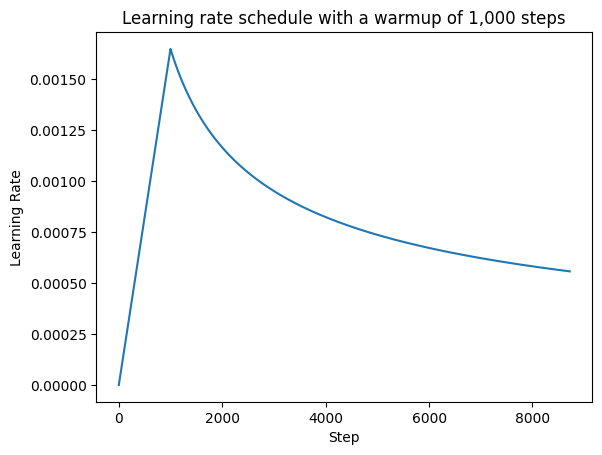

In [39]:
# 학습률 곡선 미리 확인

import matplotlib.pyplot as plt

steps = range(1, len(train_dataloader) * 20 + 1)  # 20 epoch 기준
lrs = [learning_rate(s) for s in steps]

plt.plot(steps, lrs)
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Learning rate schedule with a warmup of 1,000 steps")
plt.show()

In [40]:
EPOCHS = 20
patience = 3
best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ---- Train ----
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    train_loss = total_loss / dataset_count
    train_losses.append(train_loss)

    # ---- Validation ----
    total_val_loss = 0.0
    val_count = len(val_dataloader)
    for src, tgt in val_dataloader:
        loss, _, _, _ = eval_step(src, tgt, transformer)
        total_val_loss += loss.item()

    val_loss = total_val_loss / val_count
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "best_transformer.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 1, Train Loss: 93.0755, Val Loss: 8.2092


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 2, Train Loss: 8.5193, Val Loss: 4.8669


  0%|          | 0/436 [00:00<?, ?it/s]

...

Epoch 18, Train Loss: 2.2709, Val Loss: 2.3762


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 19, Train Loss: 2.1889, Val Loss: 2.3046


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 20, Train Loss: 2.1138, Val Loss: 2.2271


##### 학습 곡선 시각화

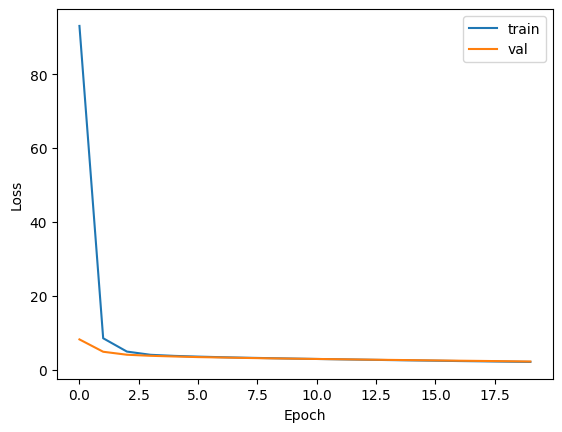

In [41]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 7. 모델 학습 결과 학인

In [42]:
def generate_response(sentence, model, word2idx, idx2word, max_len=42, device=device):
    model.eval()

    # 1. 입력 문장 전처리 + 토큰화 (기존 파이프라인과 동일하게)
    clean = preprocess_sentence(sentence)
    tokens = mecab.morphs(clean)
    ids = [word2idx.get(tok, word2idx[UNK_TOKEN]) for tok in tokens]

    enc_input = torch.tensor([ids], dtype=torch.long).to(device)

    # 2. 디코더 입력은 <start> 토큰 하나로 시작
    dec_input = torch.tensor([[word2idx["<start>"]]], dtype=torch.long).to(device)

    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, dec_input)

        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, dec_input, enc_mask, dec_enc_mask, dec_mask)

        # 마지막 타임스텝의 예측만 사용 (가장 확률 높은 토큰 선택)
        next_token_id = predictions[0, -1, :].argmax(dim=-1).item()

        # <end> 토큰이 나오면 생성 종료
        if next_token_id == word2idx["<end>"]:
            break

        dec_input = torch.cat(
            [dec_input, torch.tensor([[next_token_id]], dtype=torch.long).to(device)],
            dim=1
        )

    # <start> 제외하고 텍스트로 변환
    output_tokens = [idx2word[idx] for idx in dec_input[0].tolist()[1:]]
    return " ".join(output_tokens)


print("답변 생성 함수 정의 완료!")

답변 생성 함수 정의 완료!


In [43]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 가 보 세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 꿈 이 라도 괜찮 죠 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 좋 은 선택 할 때 가 좋 은 모습 을 거 예요 .

4. 입력: 집에 있는다는 소리야.
   답변: 저 도 궁금 하 네요 .



현재 학습 결과, 답변 품질면에서 입력마다 다른 답변이 나오는 것을 확인할 수 있다. <br>
답변 품질 면에서, 1, 4는 자연스럽고, 3번은 문법적으로 어색한 부분이 있다. <br>
Loss가 아직 떨어지는 중이므로, epoch을 늘려서 이어서 학습하도록 한다.


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 21, Train Loss: 2.0349, Val Loss: 2.1677


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 22, Train Loss: 1.9623, Val Loss: 2.0974


  0%|          | 0/436 [00:00<?, ?it/s]

...

Epoch 38, Train Loss: 1.1442, Val Loss: 1.2919


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 39, Train Loss: 1.1092, Val Loss: 1.2658


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 40, Train Loss: 1.0773, Val Loss: 1.2378


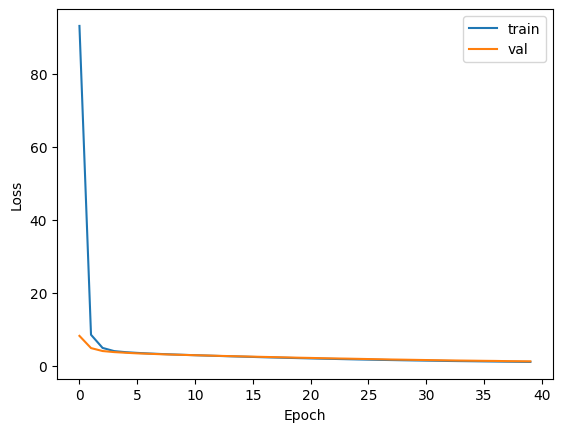

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 갈 수 있 게 좋 아요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 술 을 빌 어요 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 좋 은 선택 할 거 예요 .

4. 입력: 집에 있는다는 소리야.
   답변: 저 도 같이 가요 .



In [44]:
# 이어서 추가 학습
EXTRA_EPOCHS = 20

for epoch in range(EXTRA_EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    train_loss = total_loss / dataset_count
    train_losses.append(train_loss)

    total_val_loss = 0.0
    val_count = len(val_dataloader)
    for src, tgt in val_dataloader:
        loss, _, _, _ = eval_step(src, tgt, transformer)
        total_val_loss += loss.item()

    val_loss = total_val_loss / val_count
    val_losses.append(val_loss)

    print(f"Epoch {len(train_losses)}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "best_transformer.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {len(train_losses)}")
            break



plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

40 epoch 시점에도 train/val 둘 다 여전히 함께 떨어지고 있고, 갭도 크지 않습니다 (train 1.0773, val 1.2378, 차이 약 0.16). 아직 과적합도 확인되지 않는다. <br>
답변 품질의 경우, 3번이 이전에 비해 문법이 정리된 모습을 확인할 수 있고, 2번은 다소 어색해졌다.<br>
Loss가 아직 떨어지고 있으므로 20 epoch 더 학습 시켜보도록 한다.

In [45]:
# 이어서 추가 학습 (20 epoch 더, 총 60 epoch)
EXTRA_EPOCHS = 20

for epoch in range(EXTRA_EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    train_loss = total_loss / dataset_count
    train_losses.append(train_loss)

    total_val_loss = 0.0
    val_count = len(val_dataloader)
    for src, tgt in val_dataloader:
        loss, _, _, _ = eval_step(src, tgt, transformer)
        total_val_loss += loss.item()

    val_loss = total_val_loss / val_count
    val_losses.append(val_loss)

    print(f"Epoch {len(train_losses)}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "best_transformer.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {len(train_losses)}")
            break

  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 41, Train Loss: 1.0465, Val Loss: 1.2019


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 42, Train Loss: 1.0176, Val Loss: 1.1677


  0%|          | 0/436 [00:00<?, ?it/s]

...

Epoch 58, Train Loss: 0.6785, Val Loss: 0.8677


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 59, Train Loss: 0.6644, Val Loss: 0.8618


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 60, Train Loss: 0.6518, Val Loss: 0.8489


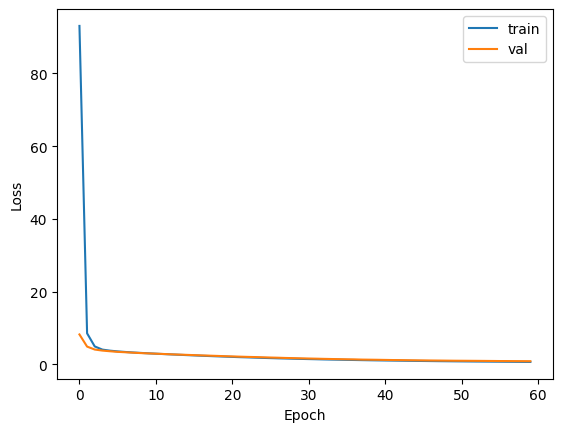

In [46]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [47]:
transformer.load_state_dict(torch.load("best_transformer.pt"))  # 최적 시점으로 로드
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 가 보 세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 술 이 문제 를 보낼지 죠 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 알뜰 한 소비 하 셨 군요 .

4. 입력: 집에 있는다는 소리야.
   답변: 저 도 같이 힘들 어요 .



개인적으로 평가했을 떄 40 epoch 때보다 60 epoch의 챗봇 품질이 더 낮아졌다. <br>
더 나은 모델을 찾기 위해서는 학습을 앞으로 돌릴 필요가 있어 보인다 <br>
안타깝게도 체크포인트를 깜박하여 best 모델을 덮어쓰기를 하는 바람에 남아있지 않으므로, 이번에는 5 epoch 마다 체크포인트를 저장하도록 한다.

In [58]:
prev_train_losses = train_losses.copy()
prev_val_losses = val_losses.copy()

In [59]:
# 모델/옵티마이저 완전 재초기화
transformer = Transformer(
    n_layers=2, d_model=368, n_heads=8, d_ff=1024,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=0.2, shared_fc=True, shared_emb=True
).to(device)

d_model = 368
learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)
optimizer = torch.optim.Adam(transformer.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)

global_step = 0
best_val_loss = float("inf")
patience_counter = 0
train_losses, val_losses = [], []

EPOCHS = 60
patience = 3

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        loss, *_ = train_step(src, tgt, transformer, optimizer)
        total_loss += loss.item()
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    train_loss = total_loss / dataset_count
    train_losses.append(train_loss)

    total_val_loss = 0.0
    val_count = len(val_dataloader)
    for src, tgt in val_dataloader:
        loss, *_ = eval_step(src, tgt, transformer)
        total_val_loss += loss.item()

    val_loss = total_val_loss / val_count
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # 5 epoch마다 별도 체크포인트 저장 (복원 가능하도록)
    if (epoch + 1) % 5 == 0:
        torch.save(transformer.state_dict(), f"/content/checkpoint_epoch_{epoch+1}.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(transformer.state_dict(), "/content/best_transformer.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 1, Train Loss: 93.4795, Val Loss: 8.2860


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 2, Train Loss: 8.3923, Val Loss: 4.8279


  0%|          | 0/436 [00:00<?, ?it/s]

...

Epoch 58, Train Loss: 0.6696, Val Loss: 0.8624


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 59, Train Loss: 0.6524, Val Loss: 0.8427


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch 60, Train Loss: 0.6399, Val Loss: 0.8342


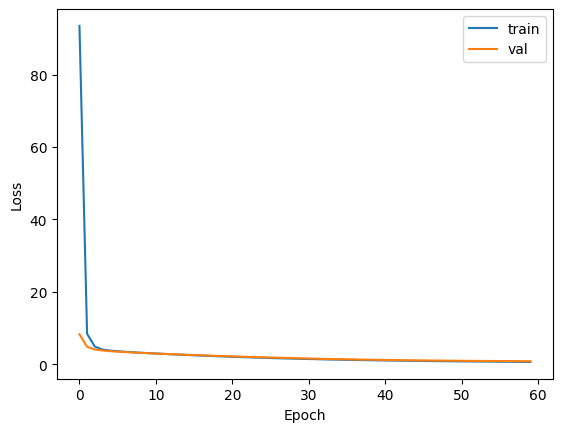

In [60]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
transformer.load_state_dict(torch.load("best_transformer.pt"))  # 최적 시점으로 로드
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 여행 은 언제나 괜찮 아요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 요즘 주무세요 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 남의 이 든 말 할 거 예요 .

4. 입력: 집에 있는다는 소리야.
   답변: 참 고 있 죠 .



In [63]:
transformer.load_state_dict(torch.load("checkpoint_epoch_35.pt"))  # 35 에폭
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 놀 러 가 세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 언젠간 당신 이 좀 더 괜찮 아 질 거 예요 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 좋 은 선택 일 거 예요 .

4. 입력: 집에 있는다는 소리야.
   답변: 제 가 다 들 어 드릴게요 .



In [62]:
transformer.load_state_dict(torch.load("checkpoint_epoch_40.pt"))  # 40 에폭
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 놀 러 가 세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 상대방 이 가장 중요 하 죠 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 건강 생각 해요 .

4. 입력: 집에 있는다는 소리야.
   답변: 저 도 같이 가요 .



In [64]:
transformer.load_state_dict(torch.load("checkpoint_epoch_45.pt"))  # 45 에폭
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 같이 놀 러 가 세요 .

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 다음 에 는 적 이 죠 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 데이트 좋 은 선택 일 거 예요 .

4. 입력: 집에 있는다는 소리야.
   답변: 뭐 든 괜찮 죠 .



In [65]:
transformer.load_state_dict(torch.load("checkpoint_epoch_50.pt"))  # 50 에폭
transformer.eval()

for i, sentence in enumerate(test_sentences, 1):
    response = generate_response(sentence, transformer, word2idx, idx2word)
    print(f"{i}. 입력: {sentence}")
    print(f"   답변: {response}")
    print()

1. 입력: 지루하다, 놀러가고 싶어.
   답변: 저 도 요 !

2. 입력: 오늘 일찍 일어났더니 피곤하다.
   답변: 다음 에 는 잘 자요 .

3. 입력: 간만에 여자친구랑 데이트 하기로 했어.
   답변: 진짜 데이트 좋 죠 .

4. 입력: 집에 있는다는 소리야.
   답변: 결국 괜찮 아 줘요 .



##### 번역 성능 측정 - BLEU Score

In [50]:
# id 텐서를 바로 받는 response 함수 재정의
def generate_from_ids(enc_input, model, word2idx, idx2word, max_len=42, device=device):
    """
    enc_input: [1, src_seq_len] 형태의 이미 패딩된 정수 텐서 (배치 1개)
    """
    model.eval()
    enc_input = enc_input.to(device)

    dec_input = torch.tensor([[word2idx["<start>"]]], dtype=torch.long).to(device)

    for _ in range(max_len):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(enc_input, dec_input)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        with torch.no_grad():
            predictions, _, _, _ = model(enc_input, dec_input, enc_mask, dec_enc_mask, dec_mask)

        next_token_id = predictions[0, -1, :].argmax(dim=-1).item()

        if next_token_id == word2idx["<end>"]:
            break

        dec_input = torch.cat(
            [dec_input, torch.tensor([[next_token_id]], dtype=torch.long).to(device)],
            dim=1
        )

    return dec_input[0].tolist()[1:]  # <start> 제외한 id 리스트 반환

In [51]:
# 특수 토큰/패딩 제거 후 단어 리스트로 변환
SPECIAL_TOKENS = {"<pad>", "<start>", "<end>", "<unk>"}

def ids_to_tokens(ids, idx2word, remove_special=True):
    tokens = [idx2word[i] for i in ids]
    if remove_special:
        tokens = [t for t in tokens if t not in SPECIAL_TOKENS]
    return tokens

In [53]:
# SmoothingFunction()으로 BLEU Score 보정

def calculate_bleu(reference, candidate, weights=[0.25, 0.25, 0.25, 0.25]):
    return sentence_bleu([reference],
                         candidate,
                         weights=weights,
                         smoothing_function=SmoothingFunction().method1)  # smoothing_function 적용

In [66]:
# val set 전체에 대해 BLEU 평균 계산

import random

random.seed(42)
sample_indices = random.sample(range(len(enc_val)), 200)
bleu_scores = {"BLEU-1": [], "BLEU-2": [], "BLEU-3": [], "BLEU-4": [], "BLEU-Total": []}

transformer.eval()
for i in sample_indices:
    enc_sample = enc_val[i:i+1]
    gold_ids = dec_val[i].tolist()
    reference = ids_to_tokens(gold_ids, idx2word)

    pred_ids = generate_from_ids(enc_sample, transformer, word2idx, idx2word)
    candidate = ids_to_tokens(pred_ids, idx2word)
    if len(candidate) == 0:
        continue

    bleu_scores["BLEU-1"].append(calculate_bleu(reference, candidate, weights=[1, 0, 0, 0]))
    bleu_scores["BLEU-2"].append(calculate_bleu(reference, candidate, weights=[0, 1, 0, 0]))
    bleu_scores["BLEU-3"].append(calculate_bleu(reference, candidate, weights=[0, 0, 1, 0]))
    bleu_scores["BLEU-4"].append(calculate_bleu(reference, candidate, weights=[0, 0, 0, 1]))
    bleu_scores["BLEU-Total"].append(calculate_bleu(reference, candidate))

for key, scores in bleu_scores.items():
    print(f"{key}: {sum(scores)/len(scores):.4f}  (n={len(scores)})")

BLEU-1: 0.6422  (n=200)
BLEU-2: 0.5216  (n=200)
BLEU-3: 0.4316  (n=200)
BLEU-4: 0.3533  (n=200)
BLEU-Total: 0.4442  (n=200)


# 8. 최종 결과 정리

---

## 하이퍼파라미터

| 항목 | 값 |
|---|---|
| n_layers | 2 |
| d_model | 368 |
| n_heads | 8 |
| d_ff | 1024 |
| dropout | 0.2 |
| Warmup Steps | 1000 |
| Batch Size | 64 |
| Epoch At | 50 |

## Translations (50 epoch 체크포인트 기준)

> 1. 지루하다, 놀러가고 싶어.
>    → 저 도 요 !
>
> 2. 오늘 일찍 일어났더니 피곤하다.
>    → 다음 에 는 잘 자요 .
>
> 3. 간만에 여자친구랑 데이트 하기로 했어.
>    → 진짜 데이트 좋 죠 .
>
> 4. 집에 있는다는 소리야.
>    → 결국 괜찮 아 줘요 .

## BLEU Score (val set 200개 샘플 기준, 50 epoch)

| 지표 | 점수 |
|---|---|
| BLEU-1 | 0.6422 |
| BLEU-2 | 0.5216 |
| BLEU-3 | 0.4316 |
| BLEU-4 | 0.3533 |
| BLEU-Total | 0.4442 |

## 모델 선택 과정 요약

1. **학습률 스케줄링 버그 수정**: 초기 `warmup_steps=60` 설정 및 `optimizer` 학습률이 매 step 갱신되지 않던 문제를 발견하고 수정 (`train_step` 내 `global_step` 기반 lr 갱신 추가). 수정 전에는 모든 입력에 대해 "사랑 하 는 게 좋 겠 어요" 같은 동일한 답변만 생성되는 **generic response collapse** 현상이 있었음.
2. **하이퍼파라미터 튜닝**: 데이터 규모(약 3만 개)에 비해 과도한 기본 설정(`d_model=512, d_ff=2048`)을 축소(`d_model=368, d_ff=1024`)하고, `warmup_steps`를 60 → 1000으로 조정.
3. **Epoch별 비교**: 40 / 45 / 50 / 60 epoch 체크포인트를 저장하여 비교한 결과, val loss는 epoch이 늘어날수록 계속 낮아졌으나 **train-val loss gap이 서서히 벌어지는 경향**이 관찰됨. 실제 생성 답변의 정성 평가에서는 **50 epoch이 가장 안정적으로 자연스러운 답변**을 생성하여 이를 최종 모델로 채택함.
4. **BLEU 지표의 한계**: train/val 분리를 Lexical Substitution 증강 **이후**에 수행하여(3만 개 이상의 학습 데이터 확보라는 평가 기준을 충족하기 위한 선택), train과 val 사이에 유사 문장이 섞여 있는 leakage가 존재함. 이로 인해 epoch이 늘어날수록 BLEU는 계속 상승하는 경향을 보였으나(60 epoch BLEU-Total 0.4967 > 50 epoch 0.4442), 이는 "학습 데이터 패턴의 재현력"에 가까운 지표이며 완전히 새로운 입력에 대한 일반화 성능과는 다소 괴리가 있었음. 따라서 **정량 지표(BLEU)보다 정성 평가(새로운 예문에 대한 응답 자연스러움)를 최종 모델 선택의 우선 기준으로 삼음.**

# NOTE

---

```text
이번 프로젝트에서 가장 인상 깊었던 부분은 loss와 실제 생성 품질이 항상 비례하지 않는다는 걸 직접 확인한 것이다. 학습을 진행할수록 val loss는 계속 낮아졌지만, 정작 새로운 문장에 대한 답변은 40~50 epoch 구간이 60 epoch보다 오히려 더 자연스러웠다.
BLEU 점수 역시 60 epoch에서 더 높게 나왔는데, 이는 augmentation 이후 train/val을 분리하면서 생긴 두 세트 간 유사성(leakage) 때문으로 보인다. 정량 지표 하나만 보고 모델을 고르면 안 된다는 걸 몸으로 배운 경험이었다.
또한 학습률 스케줄러를 정의만 해두고 실제로는 적용하지 않고 있었던 버그를 발견하고 수정한 과정이 기억에 남는다. 이 버그가 있을 때는 모든 입력에 거의 같은 답변만 나오는 문제가 있었는데, 원인을 코드 레벨에서 하나씩 짚어가며 찾아낸 게 이번 프로젝트에서 가장 크게 배운 디버깅 경험이었다.
아쉬운 점은 체크포인트를 처음부터 세밀하게 저장하지 않아서, 좋은 성능을 보였던 특정 시점(40 epoch)의 가중치를 복원할 수 없었던 것이다. 다음 프로젝트에서는 학습 초반부터 일정 주기로 체크포인트를 저장하는 습관을 들여야겠다.
```